This notebook uses matrix-based entropy [1, 2, 3] to analyze the "mutual information plane" of pretrained LLMs. 

Authors: Oscar Skean

# The Matrix-based Entropy Quantity Description

Matrix-based entropy was first proposed in [1]. It is a quantity which serves as a tractable surrogate for traditional Shannon's entropy. It's calculated using a kernel $\kappa$ on a batch of samples drawn from a distribution, without making explicit assumptions on what the true distribution is. Before introducing matrix-based entropy, it would be helpful to introduce its traditional information theory analogue called Renyi entropy, given by:

\begin{equation}
\tag{Renyi Entropy}
H_{\alpha}({P}) = \frac{1}{1-\alpha}\log{\sum_{i-1}^n p_i^{\alpha}}
\end{equation}

The Renyi entropy is a family of entropies parameterized by $\alpha$. Notable special cases are $\alpha=0$ (max-entropy), $\displaystyle \lim_{\alpha \rightarrow 1}$ (Shannon entropy), and $\alpha=2$ (collision entropy). A good writeup of Renyi entropy and the usecases of different choices of $\alpha$ is given in [4].

The definition of matrix-based entropy is given as follows.
Given a infinitely divisible kernel $\kappa$, we first construct a Gram matrix $\mathbf{K}_{\mathbf{X}} \in \mathbb{R}^{\textrm{N} \times \textrm{N}}$ consisting of all pairwise evaluations of the $N$ points in $\mathbf{X}$. The choice of $\kappa$ can be fairly flexible and could be a Gaussian kernel, linear kernel, Laplacian kernel, etc. Given $\mathbf{K}_{\mathbf{X}}$, the matrix-based entropy of order $\alpha>0$ is defined as:
\begin{equation}
\tag{Matrix-based Entropy}
S_{\alpha}\left(\mathbf{K}_{\mathbf{X}}\right) = \frac{1}{1-\alpha}\log{\left[\textrm{tr}{\left( \left( \frac{\mathbf{K}_{\mathbf{X}}}{\textrm{tr}(\mathbf{K}_{\mathbf{X}})} \right)^{\alpha}\right) }\right]},
\end{equation}

 Raising a matrix to the power of an arbitary real-valued $\alpha$ is in general difficult, so using the fact that $tr(A) = \sum_{i=1}^n \lambda_i(A)$ we can equivalently compute the above as:

\begin{equation}
\tag{Matrix-based Entropy}
S_{\alpha}\left(\mathbf{K}_{\mathbf{X}}\right) = \frac{1}{1-\alpha}\log{\left[ \sum_{i=1}^N \frac{\lambda_i(\mathbf{K}_{\mathbf{X}})}{\textrm{tr}(\mathbf{K}_{\mathbf{X}})} \right]},
\end{equation}

Notice how the matrix $\mathbf{K}_{\mathbf{X}}$ is normalized before being raised to the $\alpha$ power. This is so that the eigenvalues of $\mathbf{K}_{\mathbf{X}}$ all sum to one (as per $tr(A) = \sum_{i=1}^n \lambda_i(A)$), which is a necessary condition to treat the eigenvalues as a probability distribution. The eigenvalues of $\mathbf{K}_{\mathbf{X}}$ signify the variance of datapoints in a particular principal component direction. Therefore Equation 3 is reminescent to the so called $logdet$ entropy which captures how much "volume" a dataset occupies. However, there are many hyperparameters involved in the logdet computation to improve stability and, in my experience, the above equation is much more stable.

Like Shannon's entropy, the matrix-based entropy acts as a building block for more complex quantites such as joint entropy and mutual information. The definitions for several important matrix-based quantities are given below. Note that $\kappa$ can be any infinitely divisible kernel or corresponding covariance matrix. The following definitions are rigously introduced in [1] and gently summarized in [2].

### Matrix-based joint entropy
In the following, the $\circ$ operation is the Hadamard product aka elementwise product.
\begin{equation}
\tag{Joint Entropy}
S_{\alpha}\left(\mathbf{K}_{\mathbf{X}}, \mathbf{K}_{\mathbf{Y}} \right) = S_{\alpha}(\mathbf{K}_\mathbf{X} \circ \mathbf{K}_\mathbf{Y})
\end{equation}

### Matrix-based conditional entropy

\begin{equation}
\tag{Conditional Entropy}
S_{\alpha}(\mathbf{K}_\mathbf{X} \vert \mathbf{K}_\mathbf{Y}) = S_{\alpha}(\mathbf{K}_\mathbf{X} \circ \mathbf{K}_\mathbf{Y}) - S_{\alpha}(\mathbf{K}_\mathbf{Y}). 
\end{equation}

### Matrix-based mutual information

\begin{equation}
\tag{Mutual Information}
I_{\alpha}(\mathbf{K}_\mathbf{X} ; \mathbf{K}_\mathbf{Y}) =  S_{\alpha}(\mathbf{K}_\mathbf{X}) - S_{\alpha}(\mathbf{K}_\mathbf{X} \vert \mathbf{K}_\mathbf{Y}) = S_{\alpha}(\mathbf{K}_\mathbf{X}) +  S_{\alpha}(\mathbf{K}_\mathbf{Y}) - S_{\alpha}(\mathbf{K}_\mathbf{X} \circ \mathbf{K}_\mathbf{Y}), 
\end{equation}

## Random Interesting Properties

1. If $\alpha=2$, you can avoid explicit eigendecomposition with the Frobenius norm $||A||_F^2 = \sum_{i} \sum_{j} A_{ij}^2 = \sum_i^n \lambda_i(A)^2$. The $O(n^3)$ eigendecomposition on the rhs is reduced to a $O(n^2)$ sum of matrix elements in the middle. This property was exploited in the field of self-supervised learning in [6].

2. It must be emphasized the matrix-based entropy is NOT necessarily an estimator of Shannon's entropy of the data. It is a different measure of entropy that satisfies the axioms of entropy proposed by Renyi. However, it has been shown that if $\kappa$ is a Gaussian kernel with bandwidth $\sigma$, then as batch size $N \rightarrow \infty$ and $\sigma \rightarrow 0$, then matrix-based entropy is equal to Shannon's entropy. Loosely speaking, this follows from Parzen density estimation principles where the kernel evaluation is equal to the probability of a sample under these limit conditions.

## References



1. Giraldo, Luis Gonzalo Sanchez, Murali Rao, and Jose C. Principe. "Measures of entropy from data using infinitely divisible kernels.
2. Skean, Oscar, et al. "Dime: Maximizing mutual information by a difference of matrix-based entropies. 
3. Bach, Francis. "Information theory with kernel methods."
4. https://en.wikipedia.org/wiki/R%C3%A9nyi_entropy
5. Wei, et al. "Large Language Model Evaluation via Matrix Entropy"
6. Skean, Oscar, et al. "FroSSL: Frobenius Norm Minimization for
Efficient Multiview Self-Supervised Learning"

# Entropy Code

In [4]:
# adapted from https://github.com/uk-cliplab/representation-itl/blob/main/src/repitl/matrix_itl.py
import torch

def generalizedInformationPotential(K, alpha, allow_frobenius_speedup=True):
    """Computes the generalized information 
    potential of order alpha
          GIP_alpha(K) = trace(K_^alpha), 
    where K^alpha is a matrix raised to the alpha power. 
    K_ is normalized as K_ = K / trace(K), such that 
          trace(K_) = 1.
   
    Args:
      K: (N x N) Gram matrix.
      alpha: order of the entropy.
    
    Returns:
      GIP: generalized information potential of alpha order. 
    """
    if allow_frobenius_speedup and alpha == 2:
        return frobeniusGIP(K)
    
    ek, _ = torch.linalg.eigh(K)  
    mk = torch.gt(ek, 0.0)
    mek = ek[mk]
    mek = mek / torch.sum(mek)
    GIP = torch.sum(torch.exp(alpha * torch.log(mek)))
    return GIP


def frobeniusGIP(K):
    """
    calculates entropy using the frobenius norm trick
    equivalent result to calling generalizedInformationPotential(K, alpha=2), but this is much faster

    todo: due to symmetricity of K, can be twice as fast be only considering the lower triangle
    
    Args:
        K: (N x N) Gram matrix
    """
    GIP = torch.sum(torch.pow(K, 2))
    
    # normalize so that the sum of eigenvalues is 1
    GIP /= K.shape[0]**2
    
    return GIP

def vonNeumannEntropy(K, lowRank = False, rank = None):
    n = K.shape[0]
    ek, _ = torch.linalg.eigh(K)
    if lowRank:
        ek_lr = torch.zeros_like(ek)
        ek_lr[-rank:] = ek[-rank:]
        remainder = ek.sum() - ek_lr.sum()
        ek_lr[:(n-rank)] = remainder/(n-rank)
        mk = torch.gt(ek_lr, 0.0)
        mek = ek_lr[mk]
    else:
        mk = torch.gt(ek, 0.0)
        mek = ek[mk]

    mek = mek/mek.sum()   
    H = -1*torch.sum(mek*torch.log(mek))
    return H

def matrixAlphaEntropy(K, alpha):
    """Computes the matrix based alpha-entropy
    based on the spectrum of K
        H_alpha(A) = (1/(1-alpha))log(trace(A^alpha)), 
    where A^alpha is the matrix power of alpha (A is normalized).
    
    
    Args:
      A: (N x N) Gram matrix.
      alpha: order of the entropy.
    
    Returns:
      H: alpha entropy 
    """
    # handle limit case
    if alpha==1:
        return vonNeumannEntropy(K)

    # compute generalized information Potential
    GIP = generalizedInformationPotential(K, alpha).real
    H = (1.0 / (1.0 - alpha)) * torch.log(GIP)
    return H

In [5]:
import torch
import math

def entropy_normalization(entropy, normalization, N, D):
    """
    Normalize the entropy based on the specified normalization method.

    Args:
        entropy (float): The entropy value to be normalized.
        normalization (str): The normalization method to use.
        N (int): The number of samples.
        D (int): The dimensionality of the data.

    Returns:
        float: The normalized entropy value.
    """
    assert normalization in ['maxEntropy', 'logN', 'logD', 'logNlogD', 'raw', 'length']

    if normalization == 'maxEntropy':
        entropy /= min(math.log(N), math.log(D))
    elif normalization == 'logN':
        entropy /= math.log(N)
    elif normalization == 'logD':
        entropy /= math.log(D)
    elif normalization == 'logNlogD':
        entropy /= (math.log(N) * math.log(D))
    elif normalization == 'raw':
        pass
    elif normalization == 'length':
        entropy = N

    return entropy



def compute_entropy(hidden_states, alpha=1, normalizations=['maxEntropy']):
    L, N, D = hidden_states.shape

    if N > D:
        cov = torch.matmul(hidden_states.transpose(1, 2), hidden_states) # L x N x N
    else:
        cov = torch.matmul(hidden_states, hidden_states.transpose(1, 2)) # L x D x D

    cov = torch.clamp(cov, min=0)
    entropies = [matrixAlphaEntropy(LAYER_COV.double(), alpha=alpha).item() for LAYER_COV in cov]

    return {norm: [entropy_normalization(x, norm, N, D) for x in entropies] for norm in normalizations}

# Dataloader Code

In [6]:
import os
import math
import warnings
from typing import List

import numpy as np
import torch
import tqdm
import umap
from datasets import Dataset, load_dataset, load_from_disk
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

os.environ["TOKENIZERS_PARALLELISM"] = "false"

datasets = ['wikitext', 'ai-medical-dataset']

def get_dataloader(
        tokenizer, 
        dataset_name, 
        split='train', 
        context_length_ratio=1, 
        min_length=5,
        max_length=None, 
        num_samples=10000, 
        filter_text_columns=True, 
        augment=False,
        return_dataset=False,
        max_sample_length=2048,
        num_workers=8,
        batch_size=1
    ):
    
    def find_data_key_in_examples(examples):
        if "text" in examples:
            return "text"
        elif "sentences" in examples:
            return "sentences"
        elif "query" in examples:
            return "query"
        elif "sentence1" in examples and "sentence2" in examples:
            return "sentence1"
        else:
            raise ValueError("No text or sentences column found in examples, valid columns: ", examples.keys())

    def general_tokenize_function(examples):
        data_key = find_data_key_in_examples(examples)
        sentences = examples[data_key]
        if isinstance(sentences[0], list):
            sentences = [item for sublist in sentences for item in sublist]

        if not augment:
            texts = sentences
        else:
            texts = text_augmentation(sentences) 

        return tokenizer(texts, truncation=True, max_length=max_sample_length)
    
    def medical_tokenize_function(examples):
        medical_prompt = """You are an AI Medical Assistant Chatbot, trained to answer medical questions. Below is an instruction that describes a task, paired with an response context. Write a response that appropriately completes the request.

            ### Instruction:
            {}


            ### Response:
            {}"""
        
        instructions = examples["question"]
        outputs      = examples["context"]
        texts = []
        for instruction, output in zip(instructions,  outputs):
            # Must add EOS_TOKEN, otherwise your generation will go on forever!
            text = medical_prompt.format(instruction,  output)
            texts.append(text)

        return tokenizer(texts, truncation=True, max_length=max_sample_length)
    
    def adjust_context_length(examples):
        if context_length_ratio == 1:
            return examples
        else:
            input_length = len(examples['input_ids'])
            context_length = max(2, int(input_length * context_length_ratio))
            examples['attention_mask'] = examples['attention_mask'][:context_length]
            examples['input_ids'] = examples['input_ids'][:context_length]

            return examples

    def is_not_wikipedia_heading(example):
        return not (example["text"].strip().startswith("=") and example["text"].strip().endswith("="))

    assert dataset_name in datasets or 'mteb' in dataset_name
    assert context_length_ratio <= 1

    if dataset_name == 'wikitext':
        dataset = load_dataset("wikitext", 'wikitext-103-v1')[split]
    
        # filter out unneeded samples
        num_samples = min(num_samples, len(dataset))
        dataset = dataset.select(range(num_samples))
        dataset = dataset.filter(is_not_wikipedia_heading) # filter out headings
        
        # filter out samples by lower bound and upper bound on length
        dataset = dataset.filter(lambda x: len(x['text']) >= 2*min_length) # filter out the frequent blank/small examples in the dataset
        if max_length is not None:
            dataset = dataset.filter(lambda x: len(x['text']) <= 2*max_length)

        # tokenize the dataset
        try:
            tokenized_dataset = dataset.map(general_tokenize_function, batched=True).shuffle(seed=42)
            tokenized_dataset.set_format("torch")
        except Exception as e:
            for idx, d in enumerate(dataset):
                print(idx, d)
            raise e
        
        if filter_text_columns:
            tokenized_dataset = tokenized_dataset.remove_columns(["text"])

    elif dataset_name == 'ai-medical-dataset':
        dataset = load_dataset("ruslanmv/ai-medical-dataset")[split]
    
        # filter out unneeded samples
        num_samples = min(num_samples, len(dataset))
        dataset = dataset.select(range(num_samples))

        # tokenize the dataset
        tokenized_dataset = dataset.map(medical_tokenize_function, batched=True).shuffle(seed=42)
        tokenized_dataset.set_format("torch")

        if filter_text_columns:
            tokenized_dataset = tokenized_dataset.remove_columns(["question"])
            tokenized_dataset = tokenized_dataset.remove_columns(["context"])

        # filter out samples by lower bound and upper bound on length
        tokenized_dataset = tokenized_dataset.filter(lambda x: len(x['input_ids']) >= min_length) # filter out the frequent blank/small examples in the dataset
        if max_length is not None:
            tokenized_dataset = tokenized_dataset.filter(lambda x: len(x['input_ids']) <= max_length)

    elif 'mteb' in dataset_name:
        try:
            dataset = load_dataset(dataset_name)[split]
        except KeyError as e:
            print(f"Failed to load dataset {dataset_name} with split {split} with error {e}")
            raise e

        data_key = find_data_key_in_examples(dataset[0])
        if isinstance(dataset[0][data_key], list):
            # data is splits, choose the first split
            sentences = [item for item in dataset[0][data_key]]
            dataset = Dataset.from_dict({"text": sentences})

        num_samples = min(num_samples, len(dataset))
        dataset = dataset.select(range(num_samples))

        tokenized_dataset = dataset.map(general_tokenize_function, batched=True).shuffle(seed=42)
        tokenized_dataset.set_format("torch")

        if filter_text_columns:
            for column in tokenized_dataset.column_names:
                if column not in ['input_ids', 'attention_mask']:
                    tokenized_dataset = tokenized_dataset.remove_columns([column])


    # if context_length_ratio < 1, reduce all sentences to that ratio of length
    tokenized_dataset = tokenized_dataset.map(adjust_context_length, batched=False)

    if return_dataset:
        return tokenized_dataset
    
    # form dataloader
    dataloader = DataLoader(tokenized_dataset, 
                            shuffle=False, 
                            num_workers=num_workers, 
                            batch_size=batch_size)
    return dataloader

# Make model and dataloader

In [16]:
from transformers import AutoTokenizer, AutoModel
model_path = 'EleutherAI/pythia-410m'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path, output_hidden_states=True, device_map="auto", torch_dtype=torch.float16)

dataloader = get_dataloader(tokenizer, "wikitext", split="train", num_samples=1000)


/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Tue Jan  7 13:45:40 2025).


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/825 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

# Calculate Entropies

In [17]:
results = {}

def normalize(R):
    with torch.no_grad():
        mean = R.mean(dim=0)
        R = R - mean
        norms = torch.norm(R, p=2, dim=1, keepdim=True)
        R = R/norms
    return R

with torch.no_grad():
    for batch in tqdm.tqdm(dataloader, total=len(dataloader), desc="Processing batches"):
        batch = {k: v.to(model.device) for k, v in batch.items()}

        # squeeze if needed
        if len(batch['input_ids'].shape) == 3:
            batch = {k: v.squeeze() for k, v in batch.items()}

        outputs = model(**batch)
        
        if hasattr(outputs, 'hidden_states'):
            hidden_states = outputs.hidden_states
        elif isinstance(outputs, dict) and 'hidden_states' in outputs:
            hidden_states = outputs['hidden_states']
        else:
            hidden_states = outputs

        for sample_idx in range(len(hidden_states[0])):
            if hasattr(batch, 'attention_mask'):
                pad_idx = batch['attention_mask'][sample_idx] == 0         # ignore padding tokens
            else:
                pad_idx = None

            sample_hidden_states = [
                normalize(layer_states[sample_idx][~pad_idx]) if pad_idx is not None
                else normalize(layer_states[sample_idx])
                for layer_states in hidden_states
            ]
            sample_hidden_states = torch.stack(sample_hidden_states) # L x NUM_TOKENS x D

            sample_result = compute_entropy(sample_hidden_states, alpha=1, normalizations=['maxEntropy'])
            for norm, values in sample_result.items():
                if norm not in results:
                    results[norm] = []
                results[norm].append(values)


results = {norm: np.array(values) for norm, values in results.items()}

print(results)

Processing batches: 100%|██████████| 472/472 [01:11<00:00,  6.65it/s]

{'maxEntropy': array([[0.85919503, 0.84884641, 0.87333256, ..., 0.73924429, 0.80158676,
        0.83315215],
       [0.8799051 , 0.87440341, 0.8909791 , ..., 0.64747683, 0.79043858,
        0.83758705],
       [0.85368367, 0.82824082, 0.85411556, ..., 0.71515604, 0.78968928,
        0.82228459],
       ...,
       [0.84959884, 0.83129811, 0.85541911, ..., 0.76328983, 0.80012258,
        0.82054163],
       [0.86801193, 0.86044454, 0.87929129, ..., 0.69863126, 0.81722757,
        0.85196942],
       [0.99317937, 0.97453803, 0.95750366, ..., 0.24227408, 0.43136079,
        0.94842639]])}


# Plotting

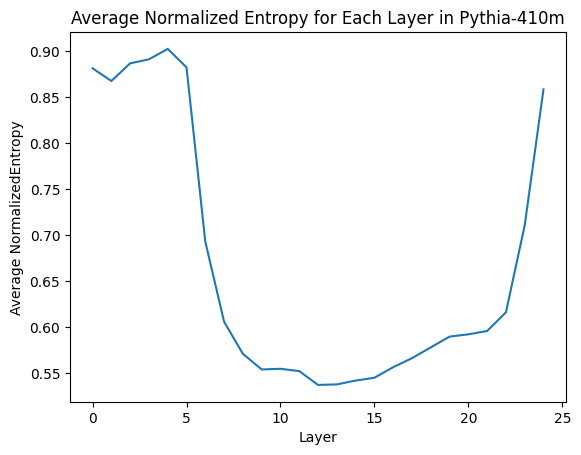

In [19]:
# plot average entropy for each layer
plt.plot(results['maxEntropy'].mean(axis=0))
plt.xlabel('Layer')
plt.ylabel('Average NormalizedEntropy')
plt.title('Average Normalized Entropy for Each Layer in Pythia-410m')
plt.show()
